In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

C:\Users\welcome\AppData\Roaming\Python\Python314\site-packages\sklearn\decomposition\_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


Recommended Movies for User 1:
Index([589, 1200, 1527, 1036, 858], dtype='int64', name='movieId')
RMSE: 2.831147078959282
Precision@5: 0.09114754098360654
Recall@5: 0.0499381416172731


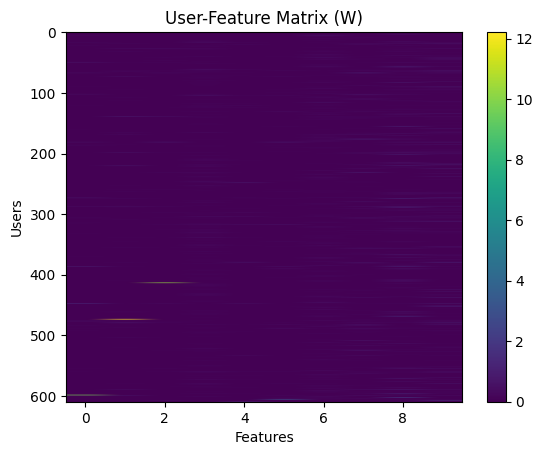

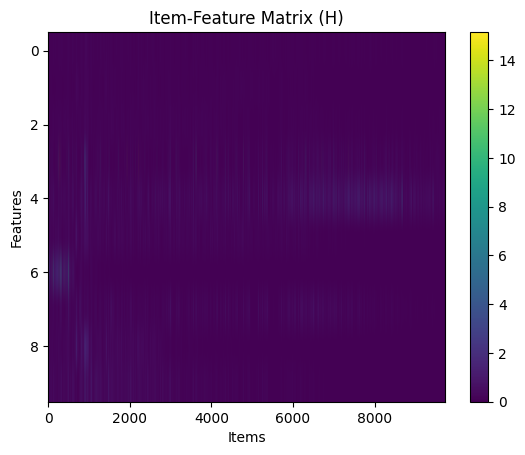

C:\Users\welcome\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


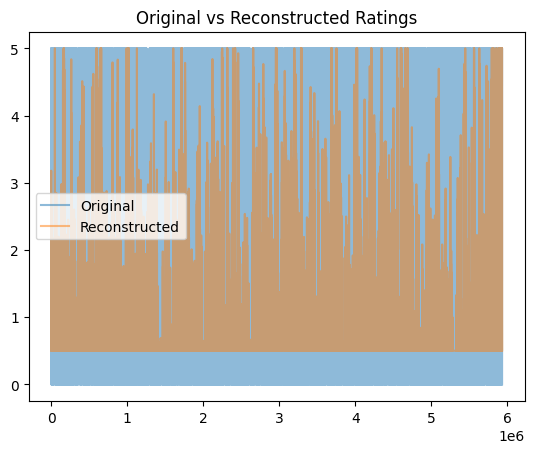

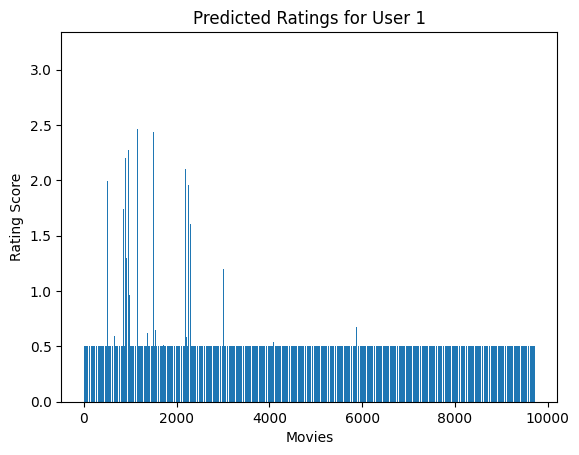

In [15]:
# Load MovieLens dataset (make sure ratings.csv is in your folder)
ratings = pd.read_csv(r"C:\Users\welcome\Downloads\archive (1)\ml-latest-small\ratings.csv")

ratings.head()

user_item_matrix = ratings.pivot(index='userId', columns='movieId', values='rating')
user_item_filled = user_item_matrix.fillna(0)

# Train-test split
train, test = train_test_split(ratings, test_size=0.2, random_state=42)

train_matrix = train.pivot(index='userId', columns='movieId', values='rating').fillna(0)
test_matrix = test.pivot(index='userId', columns='movieId', values='rating').fillna(0)

# Align matrices
train_matrix, test_matrix = train_matrix.align(test_matrix, fill_value=0)

R_train = train_matrix.values
R_test = test_matrix.values

# Apply NMF
n_components = 10
nmf_model = NMF(n_components=n_components, init='random', random_state=42, max_iter=200)

W = nmf_model.fit_transform(R_train)
H = nmf_model.components_

# Reconstruct matrix
R_pred = np.dot(W, H)

# Ensure non-negative values
R_pred = np.maximum(R_pred, 0)

# Clip to valid MovieLens rating range
R_pred = np.clip(R_pred, 0.5, 5)

# Recommendation function
def recommend_movies(user_id, R_pred, user_item_matrix, N=5):
    user_index = user_id - 1
    
    scores = R_pred[user_index].copy()
    rated = user_item_matrix.iloc[user_index].values
    
    # Remove already rated movies
    scores[rated > 0] = -1
    
    top_n = np.argsort(scores)[-N:][::-1]
    
    return user_item_matrix.columns[top_n]

# Example recommendation
print("Recommended Movies for User 1:")
print(recommend_movies(1, R_pred, user_item_filled, N=5))

# RMSE
mask = R_test > 0
rmse = np.sqrt(mean_squared_error(R_test[mask], R_pred[mask]))
print("RMSE:", rmse)

# Precision & Recall
def precision_recall_at_k(R_pred, R_test, k=5, threshold=3.5):
    precisions = []
    recalls = []
    
    for user in range(R_pred.shape[0]):
        pred = R_pred[user]
        true = R_test[user]
        
        top_k = np.argsort(pred)[-k:]
        
        relevant = true >= threshold
        recommended = np.zeros_like(pred, dtype=bool)
        recommended[top_k] = True
        
        tp = np.sum(recommended & relevant)
        
        precision = tp / k if k > 0 else 0
        recall = tp / np.sum(relevant) if np.sum(relevant) > 0 else 0
        
        precisions.append(precision)
        recalls.append(recall)
    
    return np.mean(precisions), np.mean(recalls)

precision, recall = precision_recall_at_k(R_pred, R_test, k=5)
print("Precision@5:", precision)
print("Recall@5:", recall)

# Visualization
plt.figure()
plt.imshow(W, aspect='auto')
plt.title("User-Feature Matrix (W)")
plt.xlabel("Features")
plt.ylabel("Users")
plt.colorbar()
plt.show()

plt.figure()
plt.imshow(H, aspect='auto')
plt.title("Item-Feature Matrix (H)")
plt.xlabel("Items")
plt.ylabel("Features")
plt.colorbar()
plt.show()

plt.figure()
plt.plot(R_train.flatten(), label="Original", alpha=0.5)
plt.plot(R_pred.flatten(), label="Reconstructed", alpha=0.5)
plt.legend()
plt.title("Original vs Reconstructed Ratings")
plt.show()

# Predicted ratings for a user
user_id = 1
plt.figure()
plt.bar(range(len(R_pred[user_id-1])), R_pred[user_id-1])
plt.title(f"Predicted Ratings for User {user_id}")
plt.xlabel("Movies")
plt.ylabel("Rating Score")
plt.show()